# 05 — Feature Engineering: Dataset Final (≤30 features)

Construye el dataset final que se usará en **todos los modelos**.  
El objetivo es tener ≤30 features predictivas + SK_ID_CURR + TARGET.

## Proceso
1. Leer parquets generados en los EDA (01–04)
2. Calcular features directas + engineered de `application_train`
3. Calcular aggregaciones de `bureau` + `bureau_balance`
4. Calcular aggregaciones de `previous_application`
5. Calcular aggregaciones de `installments`, `POS_CASH`, `credit_card`
6. Unir todo → dataset ancho
7. Selección final: correlación + LightGBM importances
8. Guardar `features_train.parquet` y `features_test.parquet`

## Output
- `data/processed/features_train.parquet` — 307k filas, ≤30 features + TARGET
- `data/processed/features_test.parquet`  — 49k filas, ≤30 features (sin TARGET)

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('white')
plt.rcParams['figure.dpi'] = 120

COLOR_0 = "#000986"   # azul → no default
COLOR_1 = "#fc1c03"   # rojo → default

ROOT      = os.path.abspath(os.path.join('..', '..'))
DATA_PROC = os.path.join(ROOT, 'data', 'processed')

os.makedirs(DATA_PROC, exist_ok=True)

MAX_FEATURES = 30  # restricción de features finales
print(f'ROOT: {ROOT}')

ROOT: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECMT07


## 1. application_train: features directas y engineered

In [2]:
train_raw = pd.read_parquet(os.path.join(DATA_PROC, 'app_train.parquet'))
test_raw  = pd.read_parquet(os.path.join(DATA_PROC, 'app_test.parquet'))

def build_app_features(df):
    """Features directas y engineered de application_train/test."""
    out = pd.DataFrame()
    out['SK_ID_CURR'] = df['SK_ID_CURR']
    
    # --- Features directas ---
    out['EXT_SOURCE_1'] = df['EXT_SOURCE_1']
    out['EXT_SOURCE_2'] = df['EXT_SOURCE_2']
    out['EXT_SOURCE_3'] = df['EXT_SOURCE_3']
    out['DAYS_BIRTH']   = df['DAYS_BIRTH']
    out['REGION_RATING_CLIENT_W_CITY'] = df['REGION_RATING_CLIENT_W_CITY']
    out['DAYS_ID_PUBLISH']   = df['DAYS_ID_PUBLISH']
    out['DAYS_REGISTRATION'] = df['DAYS_REGISTRATION']
    out['FLAG_DOCUMENT_3']   = df['FLAG_DOCUMENT_3']
    out['OWN_CAR_AGE']       = df['OWN_CAR_AGE']   # NaN si el cliente no tiene auto
    
    # CODE_GENDER: F=0, M=1, XNA=NaN
    out['CODE_GENDER'] = df['CODE_GENDER'].map({'F': 0, 'M': 1})
    
    # FLAG_OWN_CAR: Y=1, N=0
    out['FLAG_OWN_CAR'] = df['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0})
    
    # --- Features engineered ---
    
    # Tratar anomalía DAYS_EMPLOYED
    out['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    days_emp = df['DAYS_EMPLOYED'].replace(365243, np.nan)
    
    # Fracción de la vida laboral respecto a la edad
    out['DAYS_EMPLOYED_PERCENT'] = days_emp / df['DAYS_BIRTH']
    
    # Ratios financieros
    out['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY']    / df['AMT_INCOME_TOTAL']
    out['CREDIT_INCOME_RATIO']  = df['AMT_CREDIT']     / df['AMT_INCOME_TOTAL']
    out['CREDIT_ANNUITY_RATIO'] = df['AMT_CREDIT']     / df['AMT_ANNUITY']
    out['CREDIT_GOODS_RATIO']   = df['AMT_CREDIT']     / df['AMT_GOODS_PRICE'].replace(0, np.nan)
    out['INCOME_PER_PERSON']    = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS'].replace(0, np.nan)
    
    return out

app_train = build_app_features(train_raw)
app_train['TARGET'] = train_raw['TARGET']
app_test  = build_app_features(test_raw)

print(f'app features — train: {app_train.shape}')
print(f'app features — test : {app_test.shape}')
display(app_train.head(3))

app features — train: (307511, 20)
app features — test : (48744, 19)


,SK_ID_CURR,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,REGION_RATING_CLIENT_W_CITY,DAYS_ID_PUBLISH,DAYS_REGISTRATION,FLAG_DOCUMENT_3,OWN_CAR_AGE,CODE_GENDER,FLAG_OWN_CAR,DAYS_EMPLOYED_ANOM,DAYS_EMPLOYED_PERCENT,ANNUITY_INCOME_RATIO,CREDIT_INCOME_RATIO,CREDIT_ANNUITY_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_PERSON,TARGET
0,100002,0.083037,0.262949,0.139376,-9461,2,-2120,-3648.0,1,NaN,1.0,0,0,0.067329,0.121978,2.007889,16.461104,1.158397,202500.0,1
1,100003,0.311267,0.622246,NaN,-16765,1,-291,-1186.0,1,NaN,0.0,0,0,0.070862,0.132217,4.790750,36.234085,1.145199,135000.0,0
2,100004,NaN,0.555912,0.729567,-19046,2,-2531,-4260.0,0,26.0,1.0,1,0,0.011814,0.100000,2.000000,20.000000,1.000000,67500.0,0


## 2. bureau + bureau_balance: aggregaciones

In [3]:
buro  = pd.read_parquet(os.path.join(DATA_PROC, 'bureau.parquet'))
burob = pd.read_parquet(os.path.join(DATA_PROC, 'bureau_balance.parquet'))

# --- bureau_balance: DPD mensual → por SK_ID_BUREAU → por SK_ID_CURR ---
burob['DPD_FLAG'] = burob['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)
burob_agg = burob.groupby('SK_ID_BUREAU').agg(
    BB_DPD_MEAN=('DPD_FLAG', 'mean'),
    BB_DPD_MAX =('DPD_FLAG', 'max'),
).reset_index()
del burob; gc.collect()

# Unir bureau_balance con bureau
buro = buro.merge(burob_agg, on='SK_ID_BUREAU', how='left')

# --- Aggregaciones bureau por SK_ID_CURR ---
buro_num_agg = {
    'DAYS_CREDIT':            ['mean', 'min'],
    'CREDIT_DAY_OVERDUE':     ['max', 'mean'],
    'AMT_CREDIT_SUM':         ['sum'],
    'AMT_CREDIT_SUM_DEBT':    ['sum'],
    'AMT_CREDIT_SUM_OVERDUE': ['sum'],
    'CNT_CREDIT_PROLONG':     ['sum'],
    'SK_ID_CURR':             ['count'],
    'BB_DPD_MEAN':            ['mean'],
    'BB_DPD_MAX':             ['max'],
}

buro_agg = buro.groupby('SK_ID_CURR').agg(buro_num_agg)
buro_agg.columns = ['BURO_' + '_'.join(c).upper() for c in buro_agg.columns]
buro_agg = buro_agg.rename(columns={'BURO_SK_ID_CURR_COUNT': 'BURO_N_CREDITS'})

# Ratio deuda / crédito — clip(lower=0): el ratio no puede ser negativo.
# Valores negativos ocurren cuando AMT_CREDIT_SUM_DEBT tiene ajustes contables en "Bad debt".
buro_agg['BURO_DEBT_CREDIT_RATIO'] = (
    buro_agg['BURO_AMT_CREDIT_SUM_DEBT_SUM'] / buro_agg['BURO_AMT_CREDIT_SUM_SUM'].replace(0, np.nan)
).clip(lower=0)

# Créditos activos
active_count = (buro[buro['CREDIT_ACTIVE'] == 'Active']
                .groupby('SK_ID_CURR').size()
                .rename('BURO_CREDIT_ACTIVE_COUNT'))
buro_agg = buro_agg.merge(active_count, on='SK_ID_CURR', how='left')
buro_agg = buro_agg.reset_index()

del buro; gc.collect()
print(f'bureau features: {buro_agg.shape[1] - 1}')
display(buro_agg.head(3))

bureau features: 13


,SK_ID_CURR,BURO_DAYS_CREDIT_MEAN,BURO_DAYS_CREDIT_MIN,BURO_CREDIT_DAY_OVERDUE_MAX,BURO_CREDIT_DAY_OVERDUE_MEAN,BURO_AMT_CREDIT_SUM_SUM,BURO_AMT_CREDIT_SUM_DEBT_SUM,BURO_AMT_CREDIT_SUM_OVERDUE_SUM,BURO_CNT_CREDIT_PROLONG_SUM,BURO_N_CREDITS,BURO_BB_DPD_MEAN_MEAN,BURO_BB_DPD_MAX_MAX,BURO_DEBT_CREDIT_RATIO,BURO_CREDIT_ACTIVE_COUNT
0,100001,-735.00,-1572,0,0.0,1453365.000,596686.5,0.0,0,7,0.007519,1.0,0.410555,3.0
1,100002,-874.00,-1437,0,0.0,865055.565,245781.0,0.0,0,8,0.255682,1.0,0.284122,2.0
2,100003,-1400.75,-2586,0,0.0,1017400.500,0.0,0.0,0,4,NaN,NaN,0.000000,1.0


## 3. previous_application: aggregaciones

In [4]:
prev = pd.read_parquet(os.path.join(DATA_PROC, 'previous_application.parquet'))

prev['APP_CREDIT_RATIO'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT'].replace(0, np.nan)

prev_num_agg = {
    'AMT_ANNUITY':       ['mean'],
    'AMT_CREDIT':        ['mean'],
    'DAYS_DECISION':     ['mean'],
    'CNT_PAYMENT':       ['mean'],
    'APP_CREDIT_RATIO':  ['mean'],
    'SK_ID_PREV':        ['count'],
}
prev_agg = prev.groupby('SK_ID_CURR').agg(prev_num_agg)
prev_agg.columns = ['PREV_' + '_'.join(c).upper() for c in prev_agg.columns]
prev_agg = prev_agg.rename(columns={'PREV_SK_ID_PREV_COUNT': 'PREV_COUNT'})

# Fracción approved / refused
n_total = prev.groupby('SK_ID_CURR').size()
n_approved = (prev[prev['NAME_CONTRACT_STATUS'] == 'Approved']
              .groupby('SK_ID_CURR').size())
n_refused   = (prev[prev['NAME_CONTRACT_STATUS'] == 'Refused']
               .groupby('SK_ID_CURR').size())
prev_agg['PREV_APPROVED_RATIO'] = (n_approved / n_total).fillna(0)
prev_agg['PREV_REFUSED_RATIO']  = (n_refused  / n_total).fillna(0)

prev_agg = prev_agg.reset_index()
del prev; gc.collect()
print(f'previous_application features: {prev_agg.shape[1] - 1}')
display(prev_agg.head(3))

previous_application features: 8


,SK_ID_CURR,PREV_AMT_ANNUITY_MEAN,PREV_AMT_CREDIT_MEAN,PREV_DAYS_DECISION_MEAN,PREV_CNT_PAYMENT_MEAN,PREV_APP_CREDIT_RATIO_MEAN,PREV_COUNT,PREV_APPROVED_RATIO,PREV_REFUSED_RATIO
0,100001,3951.000,23787.0,-1740.0,8.0,1.044079,1,1.0,0.0
1,100002,9251.775,179055.0,-606.0,24.0,1.000000,1,1.0,0.0
2,100003,56553.990,484191.0,-1305.0,10.0,0.949329,3,1.0,0.0


## 4. installments, POS_CASH, credit_card: aggregaciones

In [5]:
# --- installments ---
instal = pd.read_parquet(os.path.join(DATA_PROC, 'installments.parquet'))
instal['DPD'] = (instal['DAYS_ENTRY_PAYMENT'] - instal['DAYS_INSTALMENT']).clip(lower=0)
instal['PAYMENT_RATIO'] = instal['AMT_PAYMENT'] / instal['AMT_INSTALMENT'].replace(0, np.nan)
instal['PAYMENT_DIFF']  = instal['AMT_INSTALMENT'] - instal['AMT_PAYMENT']

instal_agg = instal.groupby('SK_ID_CURR').agg(
    INSTAL_DPD_MEAN          =('DPD',           'mean'),
    INSTAL_DPD_MAX           =('DPD',           'max'),
    INSTAL_PAYMENT_RATIO_MEAN=('PAYMENT_RATIO', 'mean'),
    INSTAL_PAYMENT_DIFF_MEAN =('PAYMENT_DIFF',  'mean'),
).reset_index()
del instal; gc.collect()
print(f'installments features: {instal_agg.shape[1] - 1}')

# --- POS_CASH ---
pos = pd.read_parquet(os.path.join(DATA_PROC, 'pos_cash.parquet'))
pos_agg = pos.groupby('SK_ID_CURR').agg(
    POS_SK_DPD_MAX   =('SK_DPD',        'max'),
    POS_SK_DPD_MEAN  =('SK_DPD',        'mean'),
    POS_MONTHS_COUNT =('MONTHS_BALANCE','size'),
).reset_index()
del pos; gc.collect()
print(f'POS_CASH features: {pos_agg.shape[1] - 1}')

# --- credit_card ---
cc = pd.read_parquet(os.path.join(DATA_PROC, 'credit_card.parquet'))
cc['UTILIZATION'] = cc['AMT_BALANCE'] / cc['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
cc_agg = cc.groupby('SK_ID_CURR').agg(
    CC_AMT_BALANCE_MEAN  =('AMT_BALANCE',  'mean'),
    CC_SK_DPD_MAX        =('SK_DPD',       'max'),
    CC_SK_DPD_MEAN       =('SK_DPD',       'mean'),
    CC_UTILIZATION_MEAN  =('UTILIZATION',  'mean'),
).reset_index()
del cc; gc.collect()
print(f'credit_card features: {cc_agg.shape[1] - 1}')

installments features: 4
POS_CASH features: 3
credit_card features: 4


## 5. Unir todas las tablas

In [6]:
def merge_all(base_df):
    """Une todas las aggregaciones sobre una tabla base."""
    df = base_df.copy()
    for agg, name in [
        (buro_agg,   'bureau'),
        (prev_agg,   'previous_app'),
        (instal_agg, 'installments'),
        (pos_agg,    'pos_cash'),
        (cc_agg,     'credit_card'),
    ]:
        df = df.merge(agg, on='SK_ID_CURR', how='left')
        print(f'  + {name}: shape={df.shape}')
    return df

print('Mergeando train:')
df_train = merge_all(app_train)
print(f'\nDataset ancho train: {df_train.shape}')

print('\nMergeando test:')
df_test = merge_all(app_test)
print(f'Dataset ancho test: {df_test.shape}')

Mergeando train:
  + bureau: shape=(307511, 33)
  + previous_app: shape=(307511, 41)
  + installments: shape=(307511, 45)
  + pos_cash: shape=(307511, 48)
  + credit_card: shape=(307511, 52)

Dataset ancho train: (307511, 52)

Mergeando test:
  + bureau: shape=(48744, 32)
  + previous_app: shape=(48744, 40)
  + installments: shape=(48744, 44)
  + pos_cash: shape=(48744, 47)
  + credit_card: shape=(48744, 51)
Dataset ancho test: (48744, 51)


## 6. Selección de features finales

### Paso 1: Correlación con TARGET → descartar < |0.01|
### Paso 2: Eliminar alta colinealidad (> 0.85)
### Paso 3: Importancias de un LightGBM rápido

In [7]:
feature_cols = [c for c in df_train.columns if c not in ['SK_ID_CURR', 'TARGET']]

# --- Paso 1: correlación con TARGET ---
# corr_signed: mantiene el signo (positivo = más default, negativo = menos default)
# corr_target: valor absoluto para filtro y ranking
corr_signed = df_train[feature_cols + ['TARGET']].corrwith(df_train['TARGET']).drop('TARGET')
corr_target = corr_signed.abs().sort_values(ascending=False)

keep_step1 = corr_target[corr_target >= 0.01].index.tolist()
print(f'Paso 1 — features con |corr| >= 0.01: {len(keep_step1)} de {len(feature_cols)}')

# --- Paso 2: eliminar alta colinealidad ---
corr_matrix = df_train[keep_step1].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]
keep_step2 = [c for c in keep_step1 if c not in to_drop]
print(f'Paso 2 — tras eliminar colinealidad > 0.85: {len(keep_step2)}')

# Mostrar correlaciones con target para los candidatos
corr_final_candidates = corr_target[keep_step2].sort_values(ascending=False)
display(corr_final_candidates.head(40).to_frame('|corr con TARGET|'))

Paso 1 — features con |corr| >= 0.01: 36 de 50
Paso 2 — tras eliminar colinealidad > 0.85: 36


,|corr con TARGET|
EXT_SOURCE_3,0.178919
EXT_SOURCE_2,0.160472
EXT_SOURCE_1,0.155317
CC_UTILIZATION_MEAN,0.135560
BURO_DEBT_CREDIT_RATIO,0.091988
BURO_DAYS_CREDIT_MEAN,0.089729
CC_AMT_BALANCE_MEAN,0.087177
DAYS_BIRTH,0.078239
PREV_REFUSED_RATIO,0.077671
BURO_DAYS_CREDIT_MIN,0.075248


In [8]:
# --- Paso 3: LightGBM importances ---
try:
    import lightgbm as lgb
    
    X = df_train[keep_step2].copy()
    y = df_train['TARGET']
    
    model = lgb.LGBMClassifier(
        n_estimators=200, 
        num_leaves=31,
        learning_rate=0.05,
        n_jobs=-1,
        random_state=42,
        verbose=-1
    )
    model.fit(X, y)
    
    imp_df = pd.DataFrame({
        'feature':    keep_step2,
        'importance': model.feature_importances_,
        'abs_corr':   corr_target[keep_step2].values
    }).sort_values('importance', ascending=False)
    
    print(f'Top {MAX_FEATURES} features por importancia LightGBM:')
    display(imp_df.head(MAX_FEATURES))
    
    final_features = imp_df.head(MAX_FEATURES)['feature'].tolist()

except ImportError:
    print('lightgbm no instalado — usando top 30 por correlación con TARGET')
    final_features = corr_final_candidates.head(MAX_FEATURES).index.tolist()

print(f'\nFeatures finales seleccionadas ({len(final_features)}):')
for f in final_features:
    print(f'  {f}')

Top 30 features por importancia LightGBM:


,feature,importance,abs_corr
27,CREDIT_ANNUITY_RATIO,491,0.032102
2,EXT_SOURCE_1,440,0.155317
1,EXT_SOURCE_2,376,0.160472
0,EXT_SOURCE_3,342,0.178919
7,DAYS_BIRTH,278,0.078239
28,INSTAL_PAYMENT_DIFF_MEAN,260,0.029339
11,DAYS_EMPLOYED_PERCENT,240,0.067955
29,PREV_CNT_PAYMENT_MEAN,239,0.027743
26,PREV_AMT_ANNUITY_MEAN,233,0.034871
33,ANNUITY_INCOME_RATIO,226,0.014265



Features finales seleccionadas (30):
  CREDIT_ANNUITY_RATIO
  EXT_SOURCE_1
  EXT_SOURCE_2
  EXT_SOURCE_3
  DAYS_BIRTH
  INSTAL_PAYMENT_DIFF_MEAN
  DAYS_EMPLOYED_PERCENT
  PREV_CNT_PAYMENT_MEAN
  PREV_AMT_ANNUITY_MEAN
  ANNUITY_INCOME_RATIO
  POS_MONTHS_COUNT
  BURO_AMT_CREDIT_SUM_SUM
  CREDIT_GOODS_RATIO
  PREV_DAYS_DECISION_MEAN
  PREV_APP_CREDIT_RATIO_MEAN
  BURO_DEBT_CREDIT_RATIO
  CC_UTILIZATION_MEAN
  DAYS_ID_PUBLISH
  PREV_REFUSED_RATIO
  BURO_DAYS_CREDIT_MEAN
  BURO_CREDIT_ACTIVE_COUNT
  DAYS_REGISTRATION
  CC_AMT_BALANCE_MEAN
  PREV_AMT_CREDIT_MEAN
  OWN_CAR_AGE
  BURO_BB_DPD_MEAN_MEAN
  BURO_DAYS_CREDIT_MIN
  CODE_GENDER
  PREV_APPROVED_RATIO
  BURO_AMT_CREDIT_SUM_OVERDUE_SUM


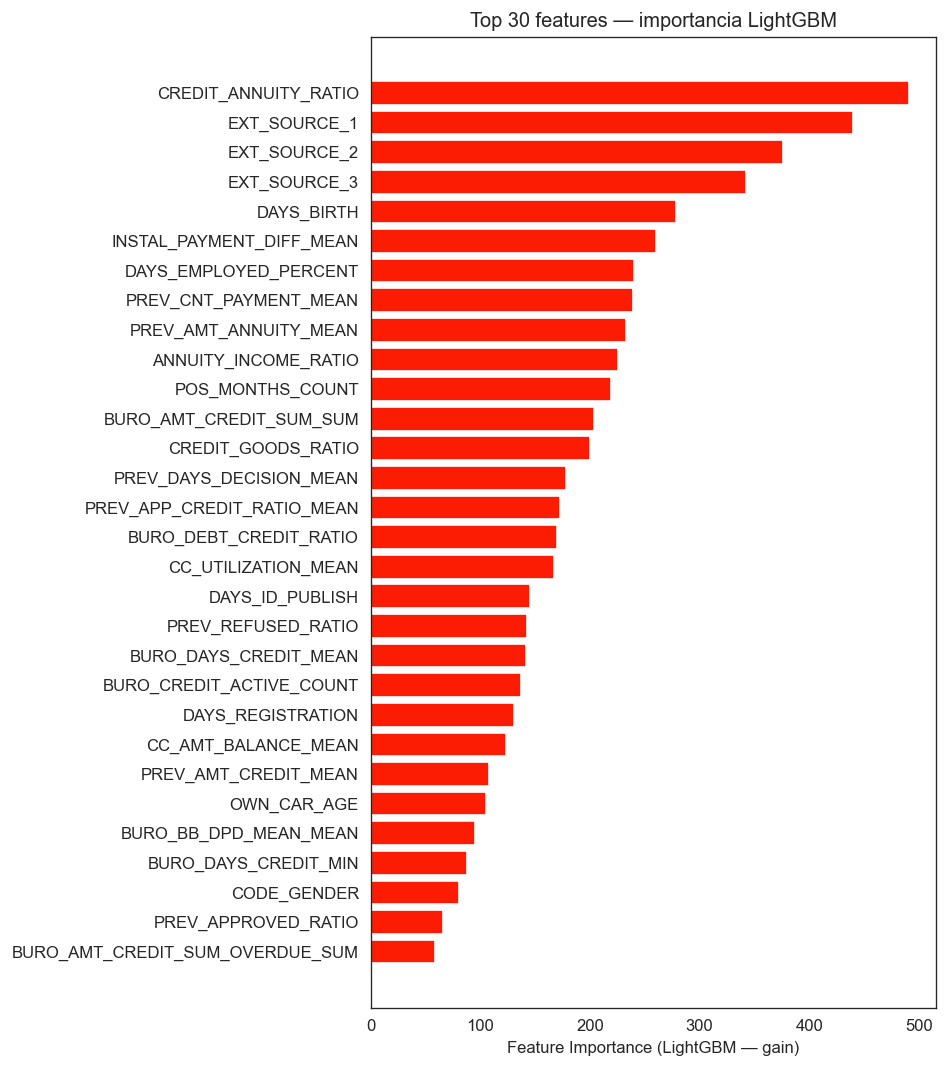

In [9]:
# Gráfico de importancias
if 'imp_df' in dir():
    # Ordenar ascending: la barra más larga (más importante) queda al tope
    top_imp_chart = imp_df.head(MAX_FEATURES).sort_values('importance', ascending=True)
    fig, ax = plt.subplots(figsize=(8, 9))
    ax.barh(top_imp_chart['feature'], top_imp_chart['importance'],
            color=COLOR_1, edgecolor='white')
    ax.set_xlabel('Feature Importance (LightGBM — gain)')
    ax.set_title(f'Top {MAX_FEATURES} features — importancia LightGBM')
    plt.tight_layout()
    plt.show()

## 7. Dataset final: matriz de correlación

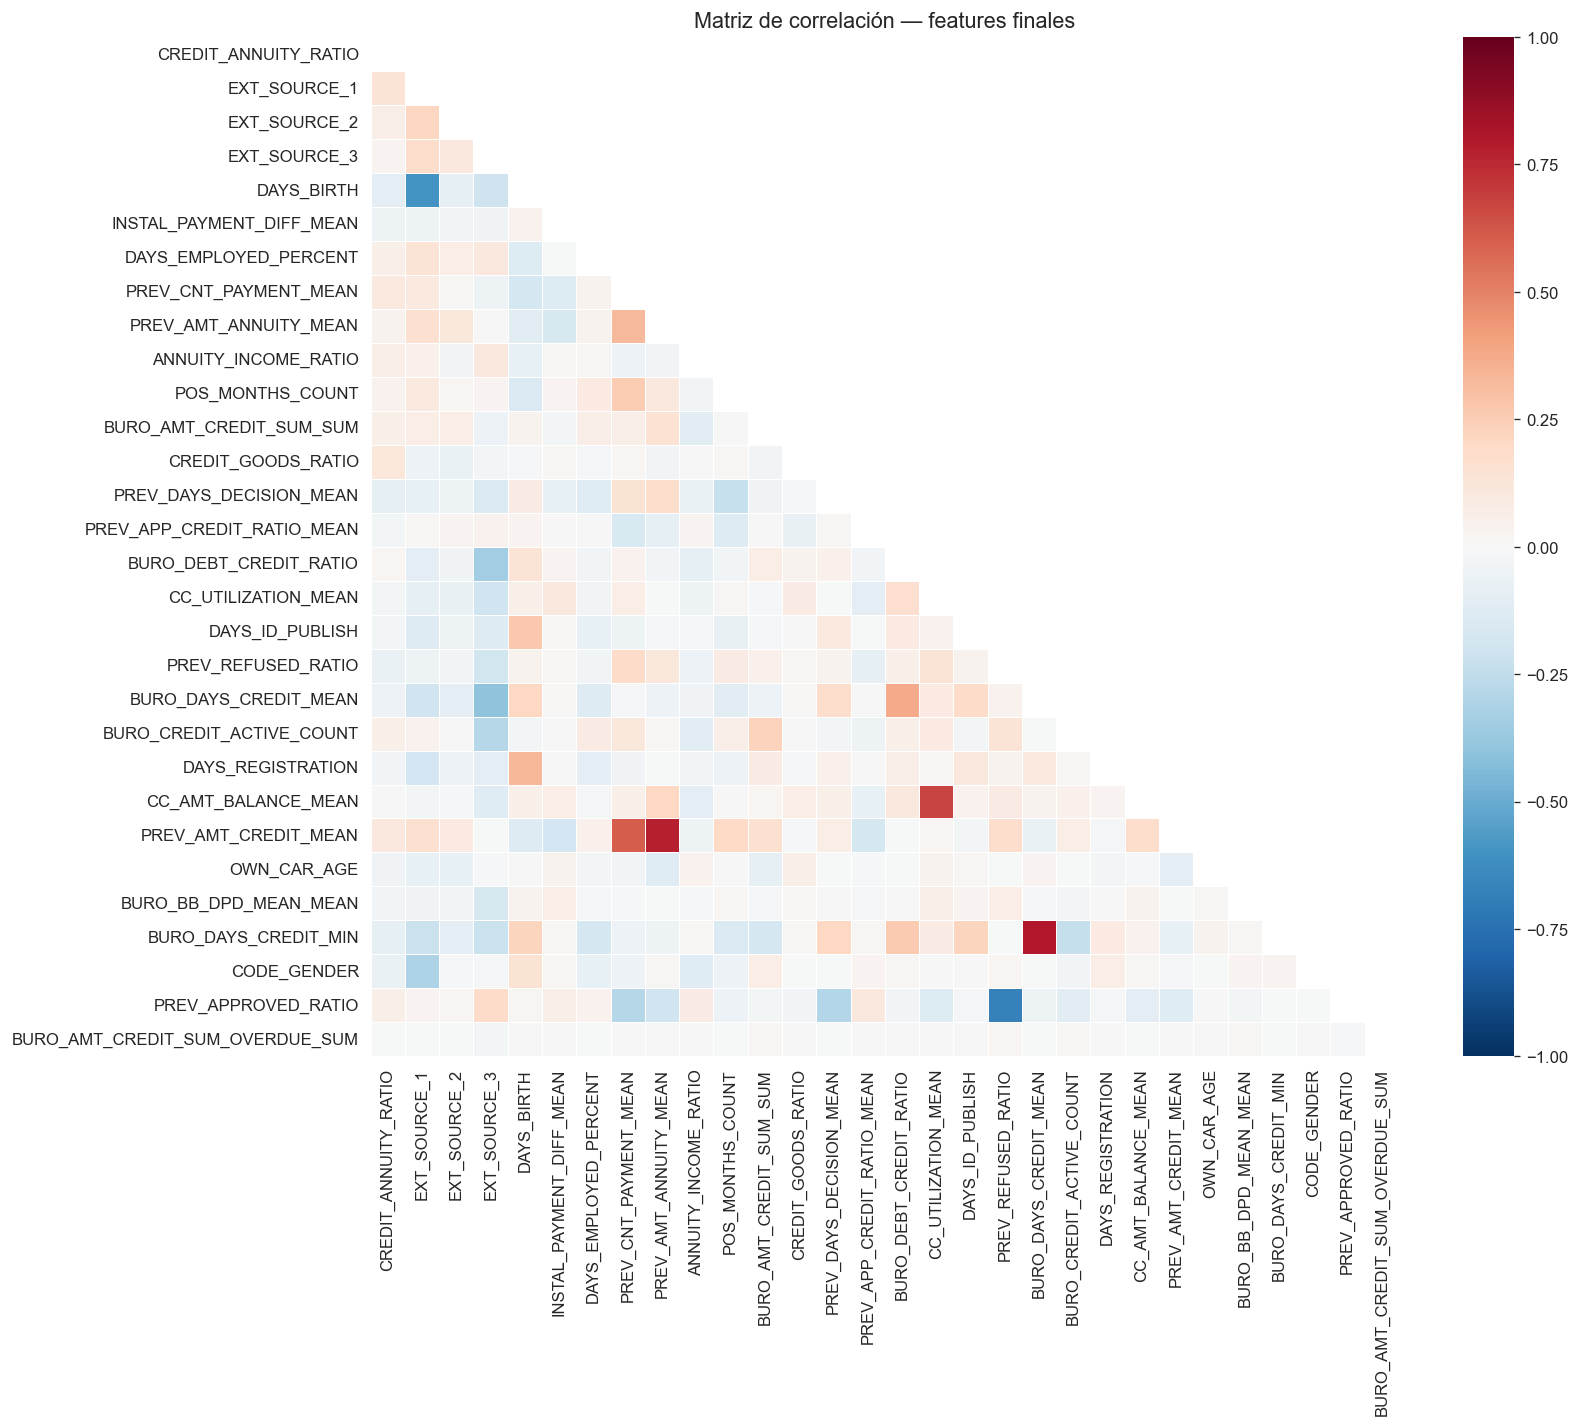

In [10]:
# Matriz de correlación entre features finales
corr_final = df_train[final_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_final, dtype=bool))
sns.heatmap(corr_final, mask=mask, annot=False, 
            cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlación — features finales', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Estadísticas finales y guardado

In [11]:
# Construir datasets finales
cols_train = ['SK_ID_CURR'] + final_features + ['TARGET']
cols_test  = ['SK_ID_CURR'] + final_features

df_final_train = df_train[cols_train].copy()
df_final_test  = df_test[cols_test].copy()

print(f'Dataset final train: {df_final_train.shape}')
print(f'Dataset final test : {df_final_test.shape}')
print(f'\nFeatures ({len(final_features)}):')
for f in final_features:
    na_pct  = df_final_train[f].isnull().mean() * 100
    corr_v  = corr_target.get(f, np.nan)
    print(f'  {f:<40s} NA={na_pct:5.1f}%  |corr|={corr_v:.4f}')

Dataset final train: (307511, 32)
Dataset final test : (48744, 31)

Features (30):
  CREDIT_ANNUITY_RATIO                     NA=  0.0%  |corr|=0.0321
  EXT_SOURCE_1                             NA= 56.4%  |corr|=0.1553
  EXT_SOURCE_2                             NA=  0.2%  |corr|=0.1605
  EXT_SOURCE_3                             NA= 19.8%  |corr|=0.1789
  DAYS_BIRTH                               NA=  0.0%  |corr|=0.0782
  INSTAL_PAYMENT_DIFF_MEAN                 NA=  5.2%  |corr|=0.0293
  DAYS_EMPLOYED_PERCENT                    NA= 18.0%  |corr|=0.0680
  PREV_CNT_PAYMENT_MEAN                    NA=  5.5%  |corr|=0.0277
  PREV_AMT_ANNUITY_MEAN                    NA=  5.5%  |corr|=0.0349
  ANNUITY_INCOME_RATIO                     NA=  0.0%  |corr|=0.0143
  POS_MONTHS_COUNT                         NA=  5.9%  |corr|=0.0356
  BURO_AMT_CREDIT_SUM_SUM                  NA= 14.3%  |corr|=0.0141
  CREDIT_GOODS_RATIO                       NA=  0.1%  |corr|=0.0694
  PREV_DAYS_DECISION_MEAN        

In [12]:
# Nota sobre NAs en dataset final:
# - Los modelos lineales requieren imputación (mediana o media)
# - Los modelos de árboles (LightGBM, XGBoost, CatBoost, RF) manejan NAs nativamente
# - La imputación se hará al inicio de cada notebook de modelo

print('Resumen de NA en dataset final:')
na_summary = df_final_train[final_features].isnull().mean().mul(100).round(2).sort_values(ascending=False)
display(na_summary[na_summary > 0].to_frame('% NA'))

Resumen de NA en dataset final:


,% NA
CC_UTILIZATION_MEAN,72.02
CC_AMT_BALANCE_MEAN,71.74
BURO_BB_DPD_MEAN_MEAN,70.01
OWN_CAR_AGE,65.99
EXT_SOURCE_1,56.38
BURO_CREDIT_ACTIVE_COUNT,29.38
EXT_SOURCE_3,19.83
DAYS_EMPLOYED_PERCENT,18.01
BURO_DEBT_CREDIT_RATIO,14.67
BURO_DAYS_CREDIT_MIN,14.31


In [13]:
# Guardar datasets finales
TRAIN_OUT = os.path.join(DATA_PROC, 'features_train.parquet')
TEST_OUT  = os.path.join(DATA_PROC, 'features_test.parquet')

df_final_train.to_parquet(TRAIN_OUT, index=False)
df_final_test.to_parquet(TEST_OUT,   index=False)

print(f'Guardado: {TRAIN_OUT}')
print(f'Guardado: {TEST_OUT}')

# Verificación rápida
check = pd.read_parquet(TRAIN_OUT)
print(f'\nVerificación — features_train.parquet: {check.shape}')
display(check.describe().T[['count', 'mean', 'std', 'min', 'max']])

Guardado: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECMT07\data\processed\features_train.parquet
Guardado: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECMT07\data\processed\features_test.parquet

Verificación — features_train.parquet: (307511, 32)


,count,mean,std,min,max
SK_ID_CURR,307511.0,2.781805e+05,1.027902e+05,1.000020e+05,4.562550e+05
CREDIT_ANNUITY_RATIO,307499.0,2.161232e+01,7.823823e+00,8.036674e+00,4.530508e+01
EXT_SOURCE_1,134133.0,5.021298e-01,2.110622e-01,1.456813e-02,9.626928e-01
EXT_SOURCE_2,306851.0,5.143927e-01,1.910602e-01,8.173617e-08,8.549997e-01
EXT_SOURCE_3,246546.0,5.108529e-01,1.948444e-01,5.272652e-04,8.960095e-01
DAYS_BIRTH,307511.0,-1.603700e+04,4.363989e+03,-2.522900e+04,-7.489000e+03
INSTAL_PAYMENT_DIFF_MEAN,291635.0,-3.638560e+02,5.210968e+03,-3.374968e+05,1.461459e+05
DAYS_EMPLOYED_PERCENT,252137.0,1.568615e-01,1.335486e-01,-0.000000e+00,7.288115e-01
PREV_CNT_PAYMENT_MEAN,290642.0,1.453082e+01,8.419878e+00,0.000000e+00,7.200000e+01
PREV_AMT_ANNUITY_MEAN,290640.0,1.453205e+04,1.000748e+04,0.000000e+00,3.004254e+05


In [14]:
print('Features finales seleccionadas para modelos (30):')
imp_lookup = imp_df.set_index('feature')['importance'] if 'imp_df' in dir() else {}
for feat in final_features:
    lgb_imp  = imp_lookup.get(feat, None)
    corr_val = corr_signed.get(feat, None)
    imp_str  = f'lgb_imp={int(lgb_imp):>5}' if lgb_imp is not None else 'lgb_imp=  n/a'
    corr_str = f'corr={corr_val:+.4f}' if corr_val is not None else 'corr=  n/a '
    print(f'  {feat:<40s} {imp_str}  {corr_str}')

Features finales seleccionadas para modelos (30):
  CREDIT_ANNUITY_RATIO                     lgb_imp=  491  corr=-0.0321
  EXT_SOURCE_1                             lgb_imp=  440  corr=-0.1553
  EXT_SOURCE_2                             lgb_imp=  376  corr=-0.1605
  EXT_SOURCE_3                             lgb_imp=  342  corr=-0.1789
  DAYS_BIRTH                               lgb_imp=  278  corr=+0.0782
  INSTAL_PAYMENT_DIFF_MEAN                 lgb_imp=  260  corr=+0.0293
  DAYS_EMPLOYED_PERCENT                    lgb_imp=  240  corr=-0.0680
  PREV_CNT_PAYMENT_MEAN                    lgb_imp=  239  corr=+0.0277
  PREV_AMT_ANNUITY_MEAN                    lgb_imp=  233  corr=-0.0349
  ANNUITY_INCOME_RATIO                     lgb_imp=  226  corr=+0.0143
  POS_MONTHS_COUNT                         lgb_imp=  219  corr=-0.0356
  BURO_AMT_CREDIT_SUM_SUM                  lgb_imp=  204  corr=-0.0141
  CREDIT_GOODS_RATIO                       lgb_imp=  200  corr=+0.0694
  PREV_DAYS_DECISION_MEAN  

## 9. Distribución del TARGET en dataset final

In [15]:
vc = df_final_train['TARGET'].value_counts()
pct = df_final_train['TARGET'].value_counts(normalize=True) * 100
print(f'TARGET=0 (paga)   : {vc[0]:>8,}  ({pct[0]:.1f}%)')
print(f'TARGET=1 (default): {vc[1]:>8,}  ({pct[1]:.1f}%)')
print(f'\nDesbalance: la clase minoritaria (default) representa el {pct[1]:.1f}% del total.')
print('→ Los modelos deben usar class_weight o scale_pos_weight para manejar el desbalance.')

TARGET=0 (paga)   :  282,686  (91.9%)
TARGET=1 (default):   24,825  (8.1%)

Desbalance: la clase minoritaria (default) representa el 8.1% del total.
→ Los modelos deben usar class_weight o scale_pos_weight para manejar el desbalance.


---
## Resumen: datasets generados

| Archivo | Filas | Columnas | Descripción |
|---------|-------|----------|-------------|
| `features_train.parquet` | 307,511 | ≤32 | Features finales + SK_ID_CURR + TARGET |
| `features_test.parquet`  | 48,744  | ≤31 | Features finales + SK_ID_CURR (sin TARGET) |

**Próximo paso**: `notebooks/4_models/06_model_logit.ipynb`